In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("imported successfully")

imported successfully


In [6]:
df = pd.read_csv('dataset1.csv')
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [8]:
df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

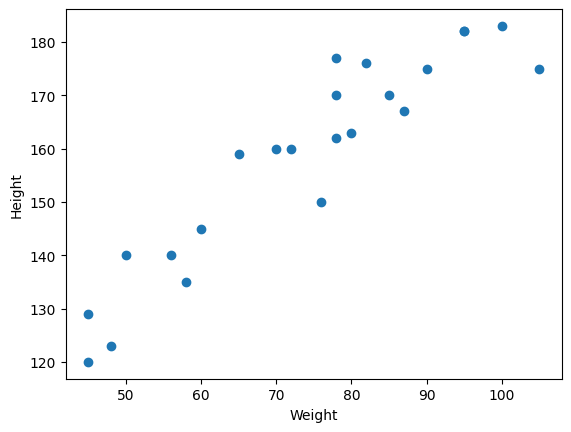

In [12]:
#sactterplot

plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")

In [14]:
##finding correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


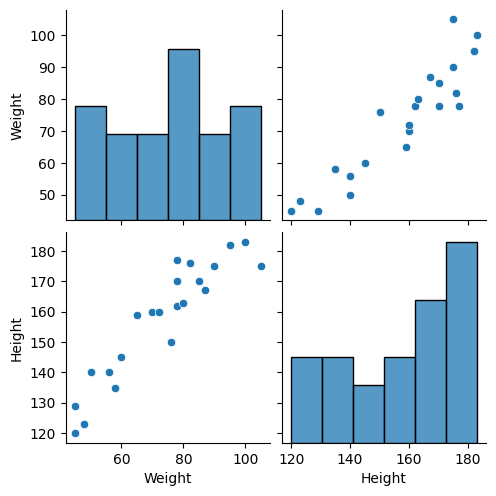

In [15]:
sns.pairplot(df)

In [ ]:
## independent and dependent feature
# X=df['Weight'] it create series with single bracket independet arrey should be a two dimension arrey or data frame
x=df[['Weight']]
y=df['Height']  # we can create like a series or one d arrey
x.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [19]:
x

,Weight
0,45
1,58
2,48
3,60
4,70
5,78
6,80
7,90
8,95
9,78


In [22]:
y

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [23]:
## train_test split

from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)##random_state is use for to equal spliting the data ,test_size = 0.25 means use tha data training purpose is 75% and rest 25% for testing

In [ ]:
##standardization
from sklearn.preprocessing import StandardScaler



In [32]:
scaler = StandardScaler()
x_train=scaler.fit_transform(x_train)
x_train


array([[-0.87662801],
       [ 1.66773133],
       [ 0.33497168],
       [-1.48242785],
       [ 1.36483141],
       [-1.6641678 ],
       [-0.75546804],
       [-0.1496682 ],
       [ 0.21381171],
       [-1.36126788],
       [-0.99778797],
       [-0.02850823],
       [ 1.06193149],
       [ 0.57729161],
       [ 0.75903157],
       [ 0.88019153],
       [ 0.45613165]])

In [33]:
x_test=scaler.transform(x_test)
x_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [37]:
## apply simple linear regression

from sklearn.linear_model import LinearRegression

In [38]:
regression = LinearRegression(n_jobs=-1)

In [39]:
regression.fit(x_train,y_train)

LinearRegression(n_jobs=-1)

In [43]:
print("coefficient or slope:=",regression.coef_)
print("intercept:=",regression.intercept_)

coefficient or slope:= [17.2982057]
intercept:= 156.47058823529412


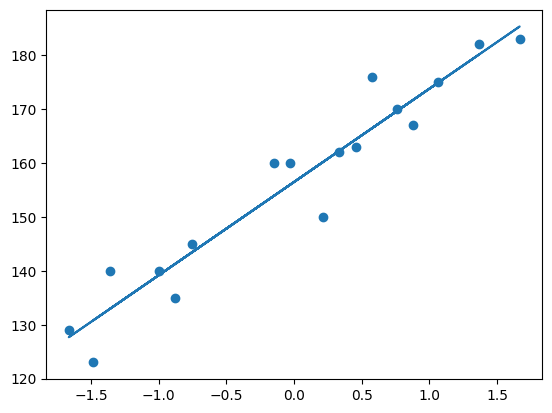

In [45]:
#plot training data plot best fit line

plt.scatter(x_train,y_train)
plt.plot(x_train,regression.predict(x_train))

In [46]:
## predication for test data 
y_pred = regression.predict(x_test)

In [48]:
# performance matrix

from sklearn.metrics import mean_absolute_error,mean_squared_error

In [50]:

mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [51]:
from sklearn.metrics import r2_score

In [52]:
score = r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [54]:
##OLS linear regression

import statsmodels.api as sm

In [55]:
model = sm.OLS(y_train,x_train).fit()

In [56]:
predicition = model.predict(x_test)
print(predicition)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [59]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 22 Jun 2025   Prob (F-statistic):                       0.664
Time:                        22:22:15   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\ASUS ROG\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\stats\_axis_nan_policy.py:418: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [64]:
## prediction for new data 
regression.predict(scaler.transform([[72]]))

array([1401.94139895])